In [1]:
# Get all files in min speed limit directory
%load_ext autoreload
%autoreload 2


import os
import sys
import glob
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.traffic_sim import *
from src.mpc_metanet import *
from src.generate_vt import *
from src.plotting import *
from src.sim_params.I24_400mParams import I24_400mParams
from src.sim_params.default import DefaultParams

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


/var/folders/kl/txwf6c7d73v3xczbyqm3trhw0000gn/T/ipykernel_89737/3714280989.py:11: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
# write a function to get the time until free flow is reached with virtual trajectories
# and plot the virtual trajectories on top of the speed field
def time_until_ff(macro_speed_field, time_step, sim_time, num_samples):
    time_between_samples = (sim_time * time_step *60) / (num_samples - 1)
    times = vt_travel_time_stats(macro_speed_field, num_samples=num_samples, time_step=time_step)
    current_ind = 0
    while (np.abs(times[current_ind] - times[current_ind + 1]) > 0.001 or np.abs(times[current_ind+1] - times[current_ind + 2]) > 0.001) and current_ind < len(times)-2:
        current_ind += 1

    return current_ind * time_between_samples
    

In [3]:
root_path = '/Users/shreyaar/Desktop/PhD/research/MPC/results/final_extended/'
# additional_path = 'holdlength'
# identifier = 'holdlen'

additional_path = 'min_speedlimit'
identifier = 'speedlimit'

# additional_path = 'spatial_safety'
# # additional_path = 'temporal_safety'
# identifier = 'safety'

# additional_path = 'gantry'
# identifier = 'location'



def get_all_files(directory, sub_dir, identifier, demand=None):
    """
    Get all files in the specified directory that match the pattern 'min_speed_limit_*.json'.
    
    Args:
        directory (str): The directory to search for files.
    
    Returns:
        list: A list of file paths that match the pattern.
    """
    #pattern = os.path.join(directory + sub_dir + '/', f'optimal_vsl_time0.0_distance6_holdlen1*{identifier}*.csv')
    if demand is not None:
        pattern = os.path.join(directory + sub_dir + '/' + f"demand{demand}/", f'{identifier}*.csv')
    else:
        pattern = os.path.join(directory + sub_dir + '/', f'{identifier}*.csv')

    return glob.glob(pattern)

def get_path_given_val(directory, sub_dir, identifier, value, demand):
    # if value >= 13:
    #     c = value if identifier == "holdlen" else 5
    # else:
    #     c = max(5, 2*value) if identifier == "holdlen" else 5
    # p = max(40, 2*c) if identifier == "holdlen" else 40
    c = max(5, value) if identifier == "holdlen" else 5
    p = max(40, 2*c) if identifier == "holdlen" else 40
    # return os.path.join(directory, sub_dir, f'optimal_vsl_time0.0_distance6_holdlen1_c{c}_p{p}_{identifier}{value}.csv')
    if demand is not None:
        return os.path.join(directory, sub_dir, f"demand{demand}/", f'{identifier}{value}.csv')
    else:
        return os.path.join(directory, sub_dir, f'{identifier}{value}.csv')

def get_constraint_range(all_paths, identifier):
    constraint_range = []
    for path in all_paths:
        # Extract the constraint value from the file name
        start_index = path.rfind(identifier) + len(identifier)
        end_index = path.rfind('.csv')
        if '.' in path[start_index:end_index]:
            constraint_value = float(path[start_index:end_index])
        else:
            constraint_value = int(path[start_index:end_index])
        constraint_range.append(constraint_value)

    return sorted(constraint_range)

In [4]:
demand_dict = dict()
for demand in [5100, 5200, 5300, 5400, 5500]:
    all_paths = get_all_files(root_path, additional_path, identifier, demand=demand)
    constraint_range = get_constraint_range(all_paths, identifier)
    print(constraint_range)
    demand_dict[demand] = (all_paths, constraint_range)

[0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100]
[0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100]
[0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100]
[0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100]
[0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100]


In [5]:
pred_horizon = 40
control_horizon = 5
sim_time = 720
time_step = 10/3600
L = 400/1000
time_steps = sim_time + pred_horizon - control_horizon

total_distance = 10
num_segments = int(total_distance/L)
sim_lanes = {i: 4 if i < num_segments-5 else 2 for i in range(num_segments)}
# sim_lanes = {i: 3 if i < num_segments-5 else 2 for i in range(num_segments)}
segment_len = L
m=num_segments
hold_len = 1

i24params = DefaultParams(num_segments).get_params()

In [6]:
i24_data = False

if i24_data:
    downstream_density = np.load('i24_data/downstream_density_400.npy').reshape(-1)
    traffic_demand = np.load('i24_data/initial_flow_400.npy').reshape(-1)

    sim_time = downstream_density.shape[0]
    time_steps = sim_time + pred_horizon - control_horizon
    while len(downstream_density) < time_steps + 1:
        downstream_density = np.append(downstream_density, downstream_density[-1])
        traffic_demand = np.append(traffic_demand, traffic_demand[-1])
else:
    downstream_density = np.full(time_steps + 1, 0)
    traffic_demand = [5500 if i in range(20, 20 + 180) else 4000 for i in range(time_steps + 1)]

In [7]:
import warnings
warnings.filterwarnings("ignore")
from generate_demand import generate_demand


cc_clipped = []
jam_times = []
demand_cc = dict()


for demand in demand_dict.keys():
    cc = []
    traffic_demand = generate_demand(sim_time, time_step, flow_standard=4000, flow_peak=demand, peak_start=20*time_step, peak_end=200*time_step)
    start_state = (np.full(num_segments, traffic_demand[0]/(sim_lanes[0] * 90)), np.full(num_segments, 90), traffic_demand[0], 0)

    _, velocity, _, no_contrl = metanet_sim_params(time_step, segment_len, start_state, np.full((sim_time, m), i24params['v_free']), traffic_demand, downstream_density, i24params,
                                    real_data=False, lanes=sim_lanes, plotting=True)

    ff_tt = num_segments * segment_len / i24params['v_free'][0]
    ff_ttt = np.sum(traffic_demand[0:sim_time]) * 10 / 3600 * ff_tt

    # path = get_path_given_val(root_path, additional_path, identifier, 0)
    # optimal_vsl = np.array(pd.read_csv(path, header=None))

    for constraint in demand_dict[demand][1]:
        # limited_vsl = np.where(optimal_vsl < constraint, constraint, optimal_vsl)
        # vsl_control_clipped = metanet_sim_params(time_step, segment_len, (np.full(m, 0), np.full(m, 0), traffic_demand[0], 0), limited_vsl, traffic_demand, downstream_density, i24params,
        #                                   lanes=sim_lanes, real_data=False)[1]
        
        path = get_path_given_val(root_path, additional_path, identifier, constraint, demand=demand)
        optimal_vsl = np.array(pd.read_csv(path))
        _, vsl_velocity, _, vsl_control = metanet_sim_params(time_step, segment_len, start_state, optimal_vsl, traffic_demand, downstream_density, i24params,
                                        lanes=sim_lanes, real_data=False, plotting=True)
        
        if demand == 5500 and constraint == 0:
            print(no_contrl)
            print(vsl_control)
        
        # vsl_velocity = np.flip(vsl_velocity.T, axis=0)
        # jam_time = time_until_ff(vsl_velocity, time_step, sim_time, num_samples=121)

        delay_current = no_contrl - ff_ttt
        delay_given_u = vsl_control - ff_ttt

        cc_i = (delay_current - delay_given_u) / (delay_current) * 100
        # cc_clipped_i = (no_contrl - vsl_control_clipped) / (no_contrl - ff_ttt) * 100
        
        cc.append(cc_i)
    
    demand_cc[demand] = cc
        # jam_times.append(jam_time)
        # cc_clipped.append(cc_clipped_i)
    

1345.2984646131933
1012.5267560910212


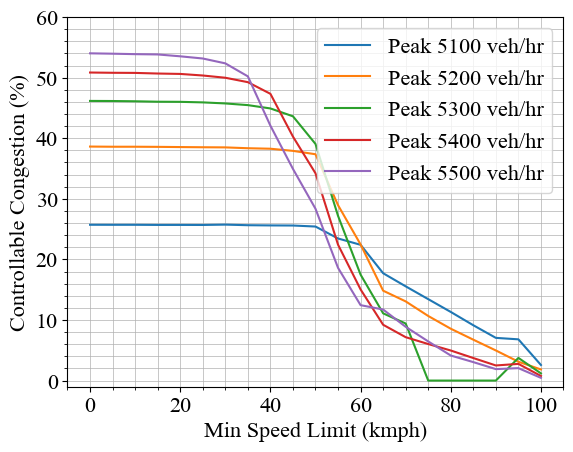

In [ ]:
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 16  # Set global font size larger

# print(demand_dict)
# print(demand_cc)

for demand in demand_dict.keys():
    if identifier == 'holdlen':
        plt.plot(np.array(demand_dict[demand][1])[:] * 10 / 60, demand_cc[demand][:], marker='o')
        plt.xlabel('Hold Length (min)', fontsize=16)
    elif identifier == 'speedlimit':
        plt.plot(np.array(demand_dict[demand][1])[:], demand_cc[demand][:], label=f'{demand} veh/hr')
        plt.xlabel('Min Speed Limit (kmph)', fontsize=16)
        plt.legend(loc='upper right')
    elif additional_path == 'spatial_safety':
        plt.plot(np.array(demand_dict[demand][1])[:], demand_cc[demand][:], marker='o')
        plt.xlabel('Max Change between Adjacent Segments (kmph)', fontsize=16)
    elif additional_path == 'temporal_safety':
        plt.plot(np.array(demand_dict[demand][1])[0:13], demand_cc[demand][0:13], marker='o')
        plt.xlabel('Max Change between Time Steps (kmph)', fontsize=16)
    elif identifier == 'location':
        plt.plot(np.array(demand_dict[demand][1]) * L, demand_cc[demand], marker='o')
        plt.xlabel('Distance from entrance (km)', fontsize=16)
        plt.vlines((num_segments - 5) * L, ymin=-1, ymax=55, colors='r', linestyles='dashed', label='bottleneck')
    plt.legend(loc='upper right')


jam = False
ax1 = plt.gca()

# Set Times New Roman for axis labels and ticks
ax1.xaxis.set_tick_params(which='both', labelsize=12)
ax1.yaxis.set_tick_params(which='both', labelsize=12)
for label in (ax1.get_xticklabels() + ax1.get_yticklabels()):
    label.set_fontname('Times New Roman')
    label.set_fontsize(16)

from matplotlib.ticker import AutoMinorLocator
ax1.xaxis.set_minor_locator(AutoMinorLocator())
ax1.yaxis.set_minor_locator(AutoMinorLocator())

if jam:
    ax2 = ax1.twinx()
    ax2.plot(np.array(constraint_range)[:], jam_times[:], marker='x', color='r', label='Time until free flow (min)')
    ax2.set_ylabel('Time until free flow (min)', color='r', fontsize=18)
    ax2.xaxis.set_minor_locator(AutoMinorLocator())
    ax2.yaxis.set_minor_locator(AutoMinorLocator())
    ax2.yaxis.set_minor_locator(plt.AutoMinorLocator())
    for label in (ax2.get_yticklabels()):
        label.set_fontname('Times New Roman')
        label.set_fontsize(16)

ax1.set_ylim(-1, 60)

ax1.set_ylabel('Controllable Congestion (%)', fontsize=16)
plt.grid(which='both', linestyle='-', linewidth=0.5)
plt.show()

(719, 25)
(720, 25)


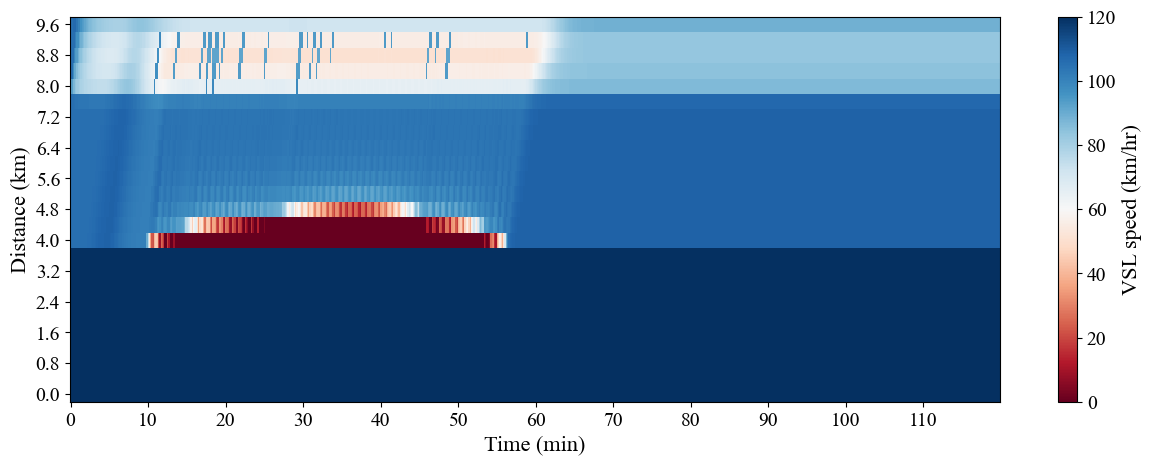

719 25


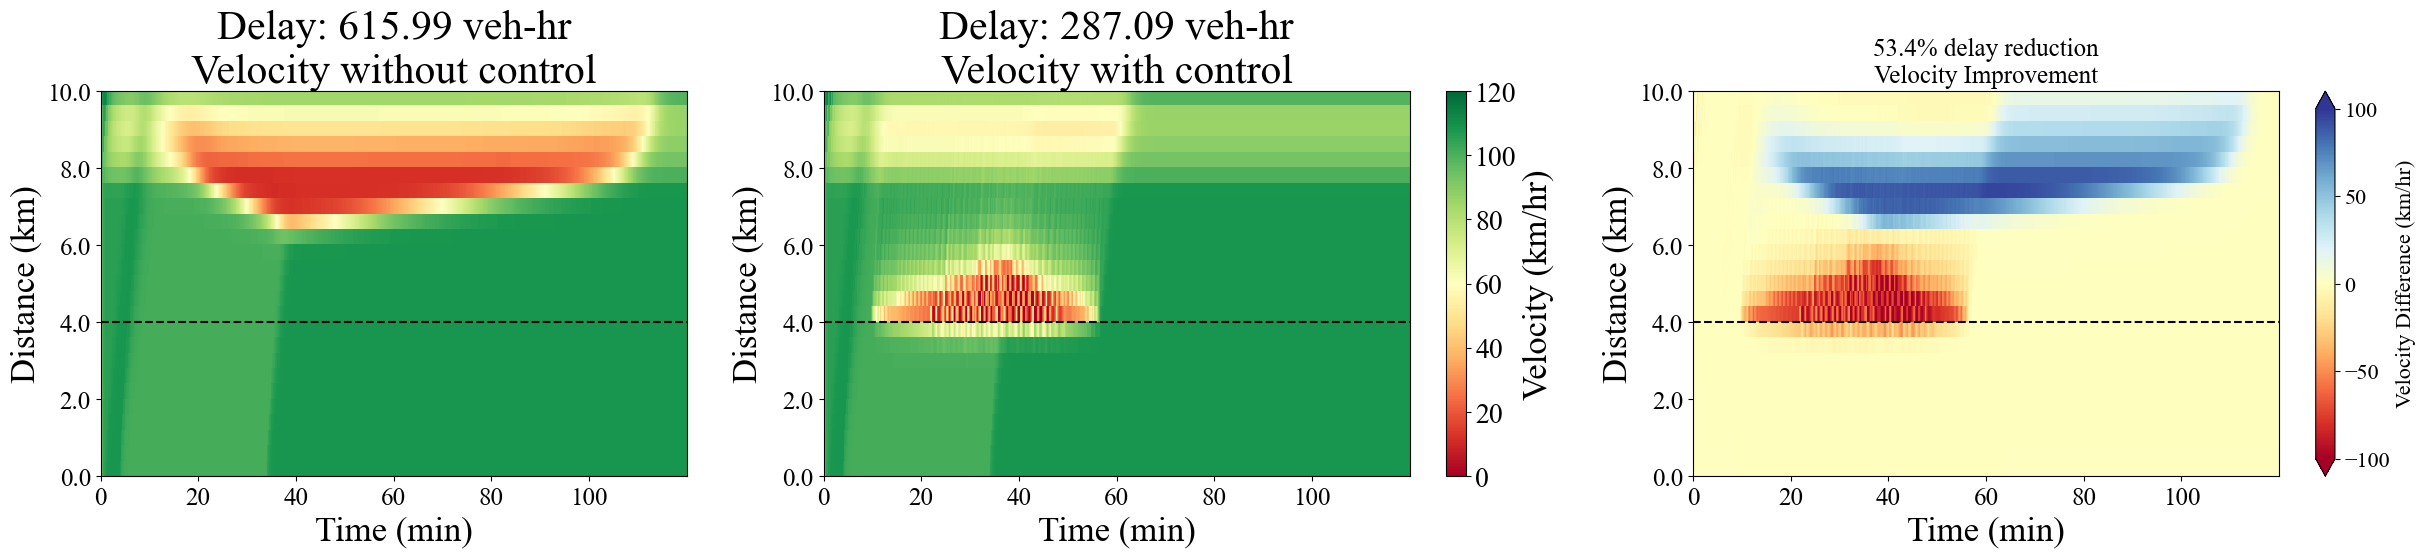

In [105]:
optimal_vsl = np.array(pd.read_csv('/Users/shreyaar/Desktop/PhD/research/MPC/results/final_extended/demand/demand5500.0_duration0.5.csv'))
optimal_vsl2 = np.array(pd.read_csv('/Users/shreyaar/Desktop/PhD/research/MPC/results/final_extended/min_speedlimit/demand5500/speedlimit0.csv'))

print(optimal_vsl.shape)
print(optimal_vsl2.shape)

plot_vsls(optimal_vsl2, sim_time, num_segments, i24params['v_free'][0], T=time_step, l=L)

plot_nocontrol_control(traffic_demand, downstream_density, optimal_vsl, sim_lanes, i24params['v_free'][0], T=time_step, l=segment_len, plot_p=False, plot_q=False, params=i24params)

In [82]:
optimal_25 = np.array(pd.read_csv(f"/Users/shreyaar/Desktop/PhD/research/MPC/results/final_extended/holdlength/holdlen40.csv"))
velocities = metanet_sim_params(time_step, segment_len, start_traffic_state, optimal_25, traffic_demand, downstream_density, i24params,
                                            lanes=sim_lanes, real_data=False, plotting=True)[1]

velocities = np.flip(velocities.T, axis=0)



/Users/shreyaar/Desktop/PhD/research/MPC/src/generate_vt.py:44: RuntimeWarning: divide by zero encountered in scalar divide
  time_to_next_space_bin = (space_current - ceil(space_current - 1)) / speed
/Users/shreyaar/Desktop/PhD/research/MPC/src/generate_vt.py:71: RuntimeWarning: divide by zero encountered in scalar divide
  time_to_previous_space_bin = (floor(space_current + 1) - space_current) / speed


Mean vehicle travel time: 21.998784535302157 min
Standard deviation of vehicle travel time: 8.29076100123488 min


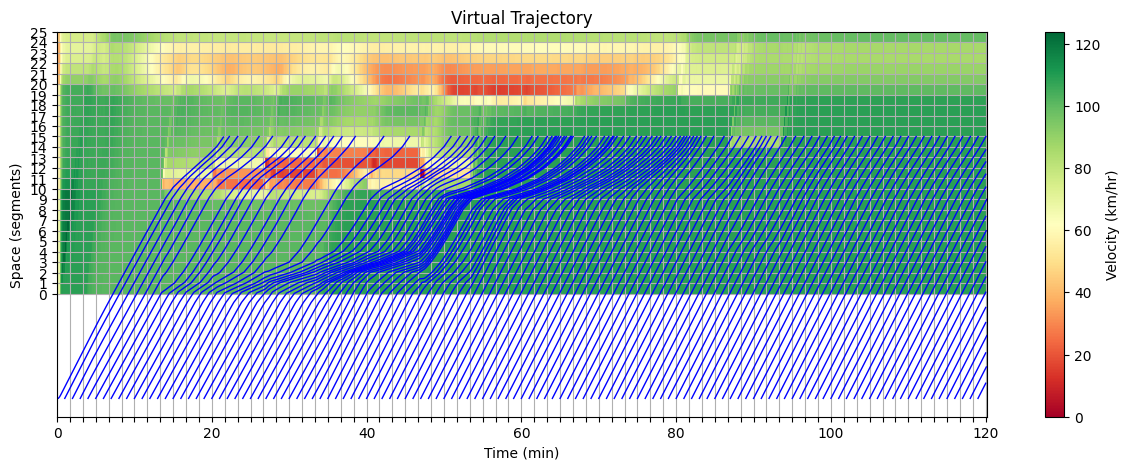

88.0


/Users/shreyaar/Desktop/PhD/research/MPC/src/generate_vt.py:44: RuntimeWarning: divide by zero encountered in scalar divide
  time_to_next_space_bin = (space_current - ceil(space_current - 1)) / speed
/Users/shreyaar/Desktop/PhD/research/MPC/src/generate_vt.py:71: RuntimeWarning: divide by zero encountered in scalar divide
  time_to_previous_space_bin = (floor(space_current + 1) - space_current) / speed


In [221]:
# print(velocities.shape)
no_control_times = vt_travel_time_stats(velocities, num_samples=121, plotting=True)
# print((no_control_times))

jam_time_25 = time_until_ff(velocities, time_step, sim_time, num_samples=121)
print(jam_time_25)
